<a href="https://colab.research.google.com/github/zachakss/chess-rating-research/blob/main/FIDE_Chess_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

df = pd.read_csv("fide_ratings_clean.csv")

In [13]:
df = df[df["month"] == "September"].copy()

In [ ]:
df["age"] = 2025 - df["birth_year"]

In [ ]:
df = df[(df["age"] >= 5) & (df["age"] <= 100)]

In [ ]:
df.to_csv("fide_ratings_cleaned_september.csv", index=False)

In [21]:
df.columns

Index(['id', 'name', 'federation', 'sex', 'title', 'rating', 'games',
       'birth_year', 'month', 'age'],
      dtype='object')

In [20]:
df["age"] = 2025 - df["birth_year"]

In [ ]:
df.shape

(203185, 10)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
federation,0
sex,0
title,190517
rating,0
games,0
birth_year,0
month,0
age,0


In [ ]:
df.head()


,id,name,federation,sex,title,rating,games,birth_year,month,age
201015,53707043,A Darshil,IND,M,NaN,1412,0,2013,September,12
201016,53200465,"A F M Ehteshamul, Hoque (tuhin",BAN,M,NaN,1797,0,1977,September,48
201017,5716365,"A Hamid, Harman",MAS,M,NaN,1552,0,1970,September,55
201018,53200553,A I Sabbir,BAN,M,NaN,1607,0,1995,September,30
201019,5045886,"A K, Kalshyan",IND,M,NaN,1747,0,1964,September,61


In [14]:
df.describe()

,id,rating,games,birth_year
count,2.031910e+05,203191.000000,203191.000000,203191.000000
mean,2.302206e+07,1743.409521,1.618915,1990.994877
std,2.303046e+07,224.758514,3.616684,20.793607
min,1.000130e+05,1400.000000,0.000000,1900.000000
25%,2.849372e+06,1563.000000,0.000000,1973.000000
50%,1.457680e+07,1713.000000,0.000000,1998.000000
75%,3.604573e+07,1884.000000,0.000000,2009.000000
max,9.479996e+07,2839.000000,40.000000,2021.000000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["sex"].value_counts()

,count
sex,
M,182109
F,21082


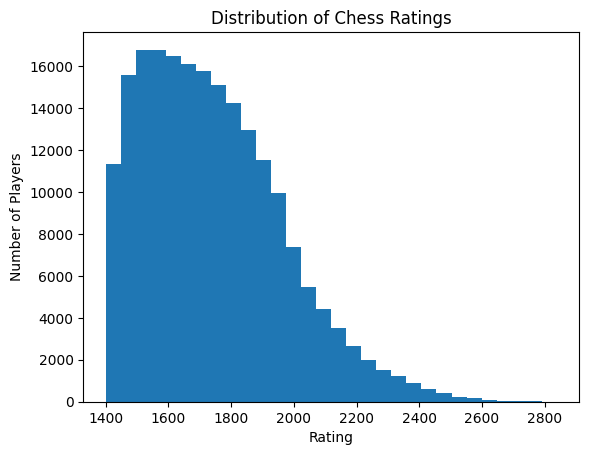

In [17]:
plt.hist(df["rating"], bins=30)

plt.title("Distribution of Chess Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Players")

plt.show()

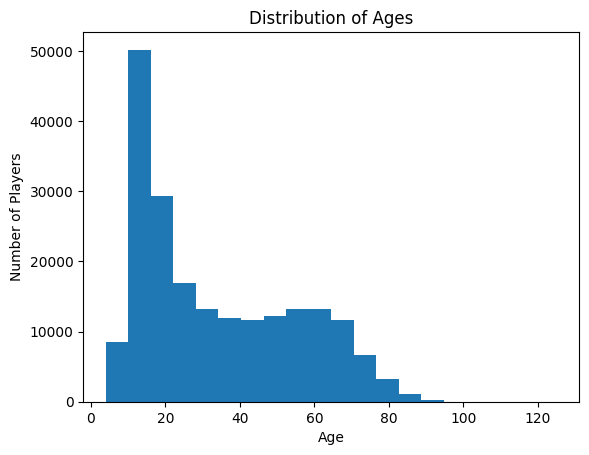

In [22]:
plt.hist(df["age"], bins=20)

plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.show()

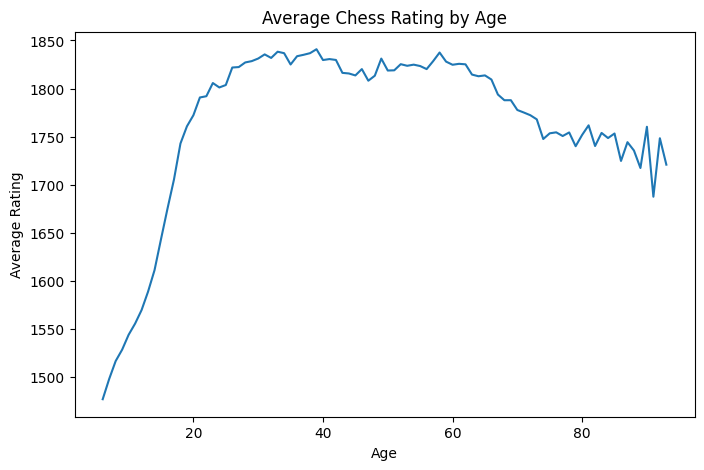

In [24]:
age_counts = df["age"].value_counts()

valid_ages = age_counts[age_counts >= 20].index

age_rating = df[df["age"].isin(valid_ages)].groupby("age")["rating"].mean()

plt.figure(figsize=(8,5))
plt.plot(age_rating.index, age_rating.values)

plt.title("Average Chess Rating by Age")
plt.xlabel("Age")
plt.ylabel("Average Rating")

plt.show()